# Supplementary Quadratic Models for Sentiment and Breadth

This notebook provides a cautious supplementary analysis of curvature in annual series selected through the residual-autocorrelation checks in the scalar LSC trend tables. The quadratic models describe possible non-linear movement alongside, rather than replacing, the primary annual estimates and linear trend summaries.


The supplementary analysis is restricted to the series selected for reporting. Autism breadth is included because the overall and clinical linear-model residuals were flagged. Sentiment is included for both targets because the clinical residuals were flagged and the quadratic models improved fit. Lived-experience series were not flagged and are omitted; overall sentiment estimates are retained as annual reference points in the sentiment figure.


In [1]:
from __future__ import annotations

from pathlib import Path

import calendar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

pd.set_option("display.max_columns", 100)


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "reports").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


PROJECT_ROOT = find_project_root()
EXPECTED_YEARS = list(range(2014, 2027))
REPORT_FRAMES = ["substantive_core_overall", "clinical_only"]
MODEL_FRAMES_BY_MEASURE = {
    "Breadth": REPORT_FRAMES,
    "Sentiment": ["clinical_only"],
}
FRAME_LABELS = {
    "substantive_core_overall": "Overall",
    "clinical_only": "Clinical",
}
FRAME_MARKERS = {
    "substantive_core_overall": "o",
    "clinical_only": "s",
}
FRAME_COLORS = {
    "ADHD": {
        "substantive_core_overall": "#2F6F9F",
        "clinical_only": "#75A9C8",
    },
    "Autism": {
        "substantive_core_overall": "#B66A4A",
        "clinical_only": "#CE8D70",
    },
}
FRAME_ORDER = {frame: index for index, frame in enumerate(REPORT_FRAMES)}
MEASURE_ORDER = {"Breadth": 0, "Sentiment": 1}
UNIT_ORDER = {"ADHD": 0, "Autism": 1}

PROCESSED_LSC_DIR = PROJECT_ROOT / "data" / "processed" / "lsc"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "lsc" / "diagnostics"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "lsc" / "diagnostics"
for directory in [FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_SUMMARY_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_models.csv"
FLAGGED_MODEL_SUMMARY_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_flagged.csv"
FLAGGED_MODEL_TABLE_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_flagged.tex"
FIGURE_DATA_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_figure_data.csv"
BREADTH_FIGURE_PATH = FIGURE_DIR / "lsc_quadratic_diagnostics_breadth_autism.png"
SENTIMENT_FIGURE_PATH = FIGURE_DIR / "lsc_quadratic_diagnostics_sentiment_targets.png"
LSC_FIGURE_DPI = 300

plt.rcParams.update(
    {
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor": "#44515C",
        "axes.labelcolor": "#25313B",
        "xtick.color": "#25313B",
        "ytick.color": "#25313B",
        "font.size": 9.5,
    }
)


## Load Completed Annual Outputs

The notebook reads the existing annual estimates and trend summaries from the completed Sentiment and Breadth runs. It does not recompute collocates, embeddings, annual scores, bootstrap intervals, or the main linear trend models.


In [2]:
sentiment_annual = pd.read_csv(PROCESSED_LSC_DIR / "sentiment" / "lsc_sentiment_annual_valence.csv")
sentiment_trends = pd.read_csv(PROCESSED_LSC_DIR / "sentiment" / "lsc_sentiment_trend_models.csv")
breadth_annual = pd.read_csv(PROCESSED_LSC_DIR / "breadth" / "lsc_breadth_annual_scores.csv")
breadth_trends = pd.read_csv(PROCESSED_LSC_DIR / "breadth" / "lsc_breadth_trend_models.csv")

source_shapes = pd.DataFrame(
    [
        {"source": "Sentiment annual", "rows": len(sentiment_annual)},
        {"source": "Sentiment trend models", "rows": len(sentiment_trends)},
        {"source": "Breadth annual", "rows": len(breadth_annual)},
        {"source": "Breadth trend models", "rows": len(breadth_trends)},
    ]
)
source_shapes


,source,rows
0,Sentiment annual,143
1,Sentiment trend models,11
2,Breadth annual,143
3,Breadth trend models,11


## Fit Supplementary Quadratic Models

Each selected annual series is fitted with a quadratic OLS model using the same centred-year convention as the main trend notebooks. Autism breadth is modelled for the overall and clinical series; sentiment is modelled only for the flagged clinical series. The compact LaTeX table reports rows whose linear-model residuals were flagged.


In [3]:
DIAGNOSTIC_SERIES = [
    {
        "measure": "Breadth",
        "analysis_unit": "Autism",
        "annual": breadth_annual,
        "trends": breadth_trends,
        "value_column": "breadth_mean_pairwise_cosine_distance",
        "ci_low_column": "breadth_ci_low",
        "ci_high_column": "breadth_ci_high",
        "y_label": "Semantic breadth",
    },
    {
        "measure": "Sentiment",
        "analysis_unit": "ADHD",
        "annual": sentiment_annual,
        "trends": sentiment_trends,
        "value_column": "valence_mean",
        "ci_low_column": "valence_ci_low",
        "ci_high_column": "valence_ci_high",
        "y_label": "Valence",
    },
    {
        "measure": "Sentiment",
        "analysis_unit": "Autism",
        "annual": sentiment_annual,
        "trends": sentiment_trends,
        "value_column": "valence_mean",
        "ci_low_column": "valence_ci_low",
        "ci_high_column": "valence_ci_high",
        "y_label": "Valence",
    },
]


def linear_trend_row(trends: pd.DataFrame, unit: str, frame_stratum: str) -> pd.Series:
    row = trends.loc[trends["analysis_unit"].eq(unit) & trends["frame_stratum"].eq(frame_stratum)]
    if row.empty:
        raise ValueError(f"No linear trend row found for {unit}/{frame_stratum}.")
    if len(row) > 1:
        raise ValueError(f"Multiple linear trend rows found for {unit}/{frame_stratum}.")
    return row.iloc[0]


def fit_quadratic_diagnostic(series: pd.DataFrame, value_column: str) -> dict[str, float | bool | str]:
    data = series[["lsc_year", value_column]].dropna().sort_values("lsc_year")
    years = data["lsc_year"].to_numpy(dtype=float)
    values = data[value_column].to_numpy(dtype=float)
    n = len(values)
    if n < 6 or len(np.unique(values)) < 3:
        raise ValueError("Quadratic diagnostic requires at least six years and three unique values.")

    year_center = float(years.mean())
    x = years - year_center
    design = np.column_stack([np.ones(n), x, x**2])
    coefficients, *_ = np.linalg.lstsq(design, values, rcond=None)
    fitted = design @ coefficients
    residuals = values - fitted
    sse = float(np.sum(residuals**2))
    sst = float(np.sum((values - values.mean()) ** 2))
    r_squared = 1 - sse / sst if sst else np.nan
    df_resid = n - design.shape[1]
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / df_resid if df_resid > 0 and not np.isnan(r_squared) else np.nan

    sigma2 = sse / df_resid if df_resid > 0 else np.nan
    covariance = sigma2 * np.linalg.inv(design.T @ design) if df_resid > 0 else np.full((3, 3), np.nan)
    standard_errors = np.sqrt(np.diag(covariance))
    t_values = coefficients / standard_errors
    p_values = 2 * stats.t.sf(np.abs(t_values), df=df_resid)

    a = float(coefficients[2])
    b = float(coefficients[1])
    if a == 0:
        vertex_year = np.nan
        vertex_score = np.nan
        vertex_in_window = False
        curvature_direction = "linear"
    else:
        vertex_x = -b / (2 * a)
        vertex_year = float(year_center + vertex_x)
        vertex_score = float(coefficients[0] + b * vertex_x + a * vertex_x**2)
        vertex_in_window = bool(min(EXPECTED_YEARS) <= vertex_year <= max(EXPECTED_YEARS))
        curvature_direction = "inverted_u" if a < 0 else "u_shaped"

    return {
        "n_years": n,
        "year_center": year_center,
        "quadratic_intercept": float(coefficients[0]),
        "quadratic_year_coef": b,
        "quadratic_year_squared_coef": a,
        "quadratic_year_coef_se": float(standard_errors[1]),
        "quadratic_year_squared_coef_se": float(standard_errors[2]),
        "quadratic_year_coef_p_value": float(p_values[1]),
        "quadratic_year_squared_coef_p_value": float(p_values[2]),
        "quadratic_r_squared": float(r_squared),
        "quadratic_adj_r_squared": float(adj_r_squared),
        "vertex_year": vertex_year,
        "vertex_score": vertex_score,
        "vertex_in_observed_window": vertex_in_window,
        "curvature_direction": curvature_direction,
    }


model_rows = []
annual_rows = []
fit_rows = []
fit_years = np.linspace(min(EXPECTED_YEARS), max(EXPECTED_YEARS), 121)

for spec in DIAGNOSTIC_SERIES:
    model_frames = MODEL_FRAMES_BY_MEASURE[spec["measure"]]
    for frame_stratum in REPORT_FRAMES:
        annual = spec["annual"]
        unit = spec["analysis_unit"]
        measure = spec["measure"]
        value_column = spec["value_column"]
        series = annual.loc[
            annual["analysis_unit"].eq(unit)
            & annual["frame_stratum"].eq(frame_stratum)
            & annual["lsc_year"].isin(EXPECTED_YEARS)
        ].sort_values("lsc_year").copy()
        if len(series) != len(EXPECTED_YEARS):
            raise ValueError(f"Expected {len(EXPECTED_YEARS)} rows for {measure}/{unit}/{frame_stratum}, found {len(series)}.")

        linear = linear_trend_row(spec["trends"], unit, frame_stratum)
        diagnostic_role = "flagged" if bool(linear["autocorrelation_flag"]) else "context"
        should_fit = frame_stratum in model_frames

        annual_out = series[["lsc_year", value_column, spec["ci_low_column"], spec["ci_high_column"]]].copy()
        annual_out = annual_out.rename(
            columns={
                value_column: "score",
                spec["ci_low_column"]: "ci_low",
                spec["ci_high_column"]: "ci_high",
            }
        )
        annual_out["measure"] = measure
        annual_out["analysis_unit"] = unit
        annual_out["frame_stratum"] = frame_stratum
        annual_out["frame_label"] = FRAME_LABELS[frame_stratum]
        annual_out["diagnostic_role"] = diagnostic_role
        annual_out["row_type"] = "annual_estimate"
        annual_out["linear_fit"] = np.nan
        annual_out["quadratic_fit_at_year"] = np.nan

        if should_fit:
            quadratic = fit_quadratic_diagnostic(series, value_column)
            linear_fitted = linear["linear_intercept"] + linear["linear_slope_per_year"] * (series["lsc_year"] - linear["year_center"])
            year_center = quadratic["year_center"]
            quadratic_fitted = (
                quadratic["quadratic_intercept"]
                + quadratic["quadratic_year_coef"] * (series["lsc_year"] - year_center)
                + quadratic["quadratic_year_squared_coef"] * (series["lsc_year"] - year_center) ** 2
            )
            quadratic_fit_grid = (
                quadratic["quadratic_intercept"]
                + quadratic["quadratic_year_coef"] * (fit_years - year_center)
                + quadratic["quadratic_year_squared_coef"] * (fit_years - year_center) ** 2
            )
            linear_fit_grid = linear["linear_intercept"] + linear["linear_slope_per_year"] * (fit_years - linear["year_center"])
            annual_out["linear_fit"] = linear_fitted.to_numpy(dtype=float)
            annual_out["quadratic_fit_at_year"] = quadratic_fitted.to_numpy(dtype=float)

            model_rows.append(
                {
                    "measure": measure,
                    "analysis_unit": unit,
                    "frame_stratum": frame_stratum,
                    "frame_label": FRAME_LABELS[frame_stratum],
                    "diagnostic_role": diagnostic_role,
                    "value_column": value_column,
                    "linear_slope_per_year": linear["linear_slope_per_year"],
                    "linear_slope_se": linear["linear_slope_se"],
                    "linear_p_value": linear["linear_p_value"],
                    "linear_adj_r_squared": linear["linear_adj_r_squared"],
                    "autocorrelation_flag": bool(linear["autocorrelation_flag"]),
                    "ar1_sensitivity_slope_per_year": linear.get("ar1_sensitivity_slope_per_year", np.nan),
                    "ar1_sensitivity_p_value": linear.get("ar1_sensitivity_p_value", np.nan),
                    **quadratic,
                    "quadratic_delta_adj_r_squared": quadratic["quadratic_adj_r_squared"] - linear["linear_adj_r_squared"],
                    "observed_2014": float(series.loc[series["lsc_year"].eq(2014), value_column].iloc[0]),
                    "observed_2026": float(series.loc[series["lsc_year"].eq(2026), value_column].iloc[0]),
                }
            )

            fit_rows.append(
                pd.DataFrame(
                    {
                        "lsc_year": fit_years,
                        "measure": measure,
                        "analysis_unit": unit,
                        "frame_stratum": frame_stratum,
                        "frame_label": FRAME_LABELS[frame_stratum],
                        "diagnostic_role": diagnostic_role,
                        "row_type": "linear_fit",
                        "fit_score": linear_fit_grid,
                    }
                )
            )
            fit_rows.append(
                pd.DataFrame(
                    {
                        "lsc_year": fit_years,
                        "measure": measure,
                        "analysis_unit": unit,
                        "frame_stratum": frame_stratum,
                        "frame_label": FRAME_LABELS[frame_stratum],
                        "diagnostic_role": diagnostic_role,
                        "row_type": "quadratic_fit",
                        "fit_score": quadratic_fit_grid,
                    }
                )
            )

        annual_rows.append(annual_out)

model_summary = pd.DataFrame(model_rows)
model_summary["measure_order"] = model_summary["measure"].map(MEASURE_ORDER)
model_summary["unit_order"] = model_summary["analysis_unit"].map(UNIT_ORDER)
model_summary["frame_order"] = model_summary["frame_stratum"].map(FRAME_ORDER)
model_summary = (
    model_summary.sort_values(["measure_order", "unit_order", "frame_order"])
    .drop(columns=["measure_order", "unit_order", "frame_order"])
    .reset_index(drop=True)
)
annual_figure_data = pd.concat(annual_rows, ignore_index=True)
fit_figure_data = pd.concat(fit_rows, ignore_index=True)
figure_data = pd.concat([annual_figure_data, fit_figure_data], ignore_index=True, sort=False)
flagged_model_summary = model_summary.loc[model_summary["autocorrelation_flag"]].copy()

model_summary.to_csv(MODEL_SUMMARY_PATH, index=False)
flagged_model_summary.to_csv(FLAGGED_MODEL_SUMMARY_PATH, index=False)
figure_data.to_csv(FIGURE_DATA_PATH, index=False)

print(f"Wrote {MODEL_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {FLAGGED_MODEL_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {FIGURE_DATA_PATH.relative_to(PROJECT_ROOT)}")
display(model_summary[[
    "measure", "analysis_unit", "frame_label", "diagnostic_role", "linear_slope_per_year", "linear_p_value",
    "linear_adj_r_squared", "quadratic_adj_r_squared", "quadratic_delta_adj_r_squared",
    "vertex_year", "vertex_in_observed_window", "autocorrelation_flag",
]])


Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_models.csv
Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.csv
Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_figure_data.csv


,measure,analysis_unit,frame_label,diagnostic_role,linear_slope_per_year,linear_p_value,linear_adj_r_squared,quadratic_adj_r_squared,quadratic_delta_adj_r_squared,vertex_year,vertex_in_observed_window,autocorrelation_flag
0,Breadth,Autism,Overall,flagged,0.000119,0.637442,-0.068103,0.510775,0.578878,2020.317193,True,True
1,Breadth,Autism,Clinical,flagged,0.000749,0.036319,0.280485,0.789346,0.508861,2021.390791,True,True
2,Sentiment,ADHD,Clinical,flagged,0.000427,0.631173,-0.067253,0.536658,0.603911,2019.682672,True,True
3,Sentiment,Autism,Clinical,flagged,0.001154,0.228067,0.049842,0.655692,0.605850,2019.220582,True,True


## Visualise Supplementary Quadratic Fits

The figures show the observed annual estimates and their bootstrap intervals, with the linear and quadratic fits overlaid for modelled series. In the sentiment panels, the overall annual estimates are retained as low-emphasis reference points while fitted lines are restricted to the clinical trajectories.


In [4]:
def style_axis(ax: plt.Axes) -> None:
    ax.grid(axis="y", color="#E7EBEE", linewidth=0.8)
    ax.grid(axis="x", color="#EEF1F3", linewidth=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#AAB4BC")
    ax.spines["bottom"].set_color("#AAB4BC")
    ax.set_xticks(EXPECTED_YEARS[::2])
    ax.tick_params(axis="x", labelsize=8.5)
    ax.tick_params(axis="y", labelsize=8.5)


def set_panel_ylim(ax: plt.Axes, measure: str, unit: str) -> None:
    annual = annual_figure_data.loc[annual_figure_data["measure"].eq(measure) & annual_figure_data["analysis_unit"].eq(unit)]
    fits = fit_figure_data.loc[fit_figure_data["measure"].eq(measure) & fit_figure_data["analysis_unit"].eq(unit)]
    y_parts = [annual["ci_low"], annual["ci_high"], annual["score"]]
    if not fits.empty:
        y_parts.append(fits["fit_score"])
    y_values = pd.concat(y_parts).dropna()
    y_min = float(y_values.min())
    y_max = float(y_values.max())
    padding = (y_max - y_min) * 0.09 if y_max > y_min else 0.01
    ax.set_ylim(y_min - padding, y_max + padding)


def plot_diagnostic_panel(ax: plt.Axes, measure: str, unit: str, *, y_label: str | None = None) -> None:
    for frame_stratum in REPORT_FRAMES:
        annual = annual_figure_data.loc[
            annual_figure_data["measure"].eq(measure)
            & annual_figure_data["analysis_unit"].eq(unit)
            & annual_figure_data["frame_stratum"].eq(frame_stratum)
        ].sort_values("lsc_year")
        line_fit = fit_figure_data.loc[
            fit_figure_data["measure"].eq(measure)
            & fit_figure_data["analysis_unit"].eq(unit)
            & fit_figure_data["frame_stratum"].eq(frame_stratum)
            & fit_figure_data["row_type"].eq("linear_fit")
        ].sort_values("lsc_year")
        quadratic_fit = fit_figure_data.loc[
            fit_figure_data["measure"].eq(measure)
            & fit_figure_data["analysis_unit"].eq(unit)
            & fit_figure_data["frame_stratum"].eq(frame_stratum)
            & fit_figure_data["row_type"].eq("quadratic_fit")
        ].sort_values("lsc_year")
        color = FRAME_COLORS[unit][frame_stratum]
        is_sentiment_reference = measure == "Sentiment" and frame_stratum == "substantive_core_overall"

        ribbon_alpha = 0.035 if is_sentiment_reference else 0.12
        line_alpha = 0.30 if is_sentiment_reference else 0.95
        line_width = 1.0 if is_sentiment_reference else 1.8
        marker_size = 3.2 if is_sentiment_reference else 4.5

        ax.fill_between(
            annual["lsc_year"].to_numpy(dtype=float),
            annual["ci_low"].to_numpy(dtype=float),
            annual["ci_high"].to_numpy(dtype=float),
            color=color,
            alpha=ribbon_alpha,
            linewidth=0,
        )
        ax.plot(
            annual["lsc_year"],
            annual["score"],
            marker=FRAME_MARKERS[frame_stratum],
            markersize=marker_size,
            linewidth=line_width,
            color=color,
            alpha=line_alpha,
            label=FRAME_LABELS[frame_stratum],
        )
        if not line_fit.empty:
            ax.plot(
                line_fit["lsc_year"],
                line_fit["fit_score"],
                color=color,
                linewidth=1.25,
                linestyle="--",
                alpha=0.75,
            )
        if not quadratic_fit.empty:
            ax.plot(
                quadratic_fit["lsc_year"],
                quadratic_fit["fit_score"],
                color=color,
                linewidth=2.2,
                linestyle="-",
                alpha=1.0,
            )
    style_axis(ax)
    set_panel_ylim(ax, measure, unit)
    if y_label:
        ax.set_ylabel(y_label, fontsize=9.5)


def save_lsc_figure(fig: plt.Figure, png_path: Path) -> Path:
    fig.savefig(png_path, dpi=LSC_FIGURE_DPI, bbox_inches="tight", facecolor="white")
    pdf_path = png_path.with_suffix(".pdf")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    return pdf_path


frame_legend_handles = [
    Line2D([0], [0], color="#44515C", marker=FRAME_MARKERS["substantive_core_overall"], linewidth=1.0, alpha=0.45, label="Overall annual estimate"),
    Line2D([0], [0], color="#44515C", marker=FRAME_MARKERS["clinical_only"], linewidth=1.8, alpha=0.95, label="Clinical annual estimate"),
]
fit_legend_handles = [
    Line2D([0], [0], color="#44515C", linestyle="--", linewidth=1.25, label="Linear fit"),
    Line2D([0], [0], color="#44515C", linestyle="-", linewidth=2.2, label="Quadratic fit"),
]
legend_handles = [*frame_legend_handles, *fit_legend_handles]


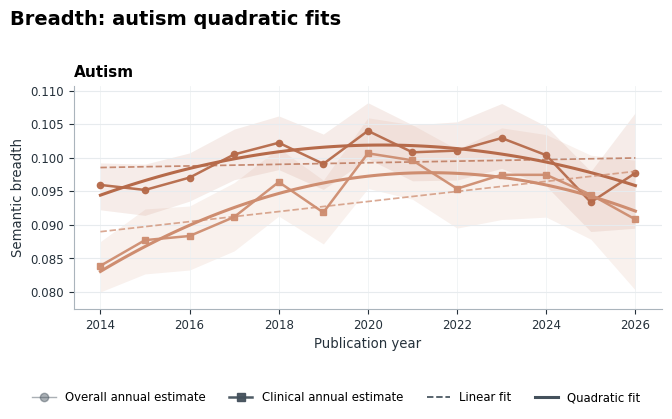

Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.png
Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.pdf


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6.8, 3.95), sharex=True)
plot_diagnostic_panel(ax, "Breadth", "Autism", y_label="Semantic breadth")
ax.set_title("Autism", loc="left", fontsize=11, fontweight="bold", pad=6)
ax.set_xlabel("Publication year", fontsize=9.5)

fig.suptitle("Breadth: autism quadratic fits", x=0.02, y=0.98, ha="left", fontsize=14, fontweight="bold")
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.045), frameon=False, fontsize=8.4, ncol=4)
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
breadth_pdf = save_lsc_figure(fig, BREADTH_FIGURE_PATH)
plt.show()
print(f"Wrote {BREADTH_FIGURE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {breadth_pdf.relative_to(PROJECT_ROOT)}")


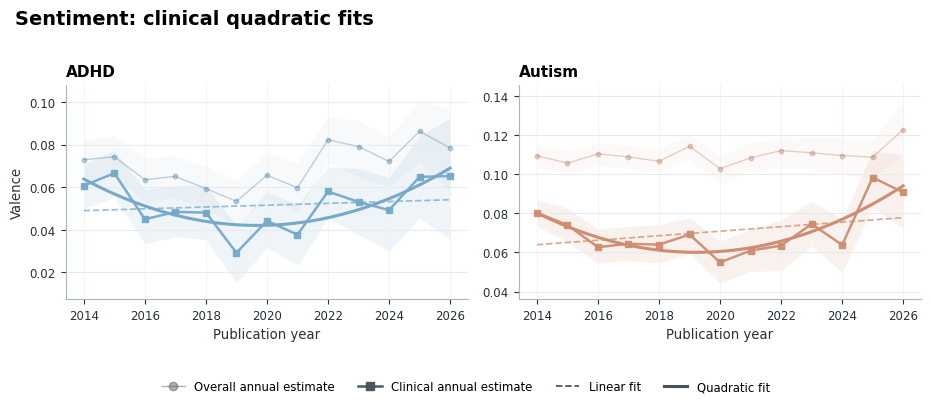

Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.png
Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.85), sharex=True, sharey=False)
for ax, unit in zip(axes, ["ADHD", "Autism"], strict=True):
    plot_diagnostic_panel(ax, "Sentiment", unit, y_label="Valence" if unit == "ADHD" else None)
    ax.set_title(unit, loc="left", fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("Publication year", fontsize=9.5)

fig.suptitle("Sentiment: clinical quadratic fits", x=0.02, y=0.98, ha="left", fontsize=14, fontweight="bold")
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.045), frameon=False, fontsize=8.4, ncol=4)
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
sentiment_pdf = save_lsc_figure(fig, SENTIMENT_FIGURE_PATH)
plt.show()
print(f"Wrote {SENTIMENT_FIGURE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {sentiment_pdf.relative_to(PROJECT_ROOT)}")


## Save Supplementary Quadratic Table

The appendix table reports only rows whose linear-model residuals were flagged for autocorrelation. Overall sentiment remains in the figure as annual reference but is not included in the table because it was not flagged.


In [7]:
def p_stars(p_value: float) -> str:
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return r"^{***}"
    if p_value < 0.01:
        return r"^{**}"
    if p_value < 0.05:
        return r"^{*}"
    return ""


def format_coef_se(coef: float, se: float, p_value: float) -> str:
    return rf"${coef:.4f}{p_stars(p_value)}$ ({se:.4f})"


def format_delta_adj_r2(value: float) -> str:
    return f"{value:.2f}"


def format_vertex(row: pd.Series) -> str:
    shape = "inverted U" if row["curvature_direction"] == "inverted_u" else "U"
    vertex_year = float(row["vertex_year"])
    year = int(np.floor(vertex_year))
    month_number = min(12, int(np.floor((vertex_year - year) * 12)) + 1)
    return f"{calendar.month_name[month_number]} {year} ({shape})"


def make_flagged_quadratic_latex(table_data: pd.DataFrame) -> str:
    rows = []
    for _, row in table_data.iterrows():
        rows.append(
            " & ".join(
                [
                    row["measure"],
                    row["analysis_unit"],
                    row["frame_label"],
                    format_coef_se(row["linear_slope_per_year"], row["linear_slope_se"], row["linear_p_value"]),
                    format_coef_se(
                        row["quadratic_year_squared_coef"],
                        row["quadratic_year_squared_coef_se"],
                        row["quadratic_year_squared_coef_p_value"],
                    ),
                    format_delta_adj_r2(row["quadratic_delta_adj_r_squared"]),
                    format_vertex(row),
                ]
            )
            + r" \\" 
        )
    body = "\n".join(rows)
    lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        r"\caption{Supplementary quadratic models for autocorrelation-flagged LSC trajectories.}",
        r"\label{tab:lsc-quadratic-diagnostics}",
        r"\scriptsize",
        r"\begin{tabular}{@{}lllcccc@{}}",
        r"\toprule",
        "Measure & Target & Frame & Linear $B(SE)$ & Quadratic $B_2(SE)$ & $\\Delta$ Adj. $R^2$ & Vertex \\\\",
        r"\midrule",
        body,
        r"\bottomrule",
        r"\end{tabular}",
        r"\parbox{\linewidth}{\footnotesize Note. Rows are restricted to annual series whose linear-model residuals were flagged for autocorrelation. Linear $B$ is the annual OLS slope from the primary trend model. Quadratic $B_2$ is the centred-year-squared coefficient; $\Delta$ Adj. $R^2$ is the adjusted-$R^2$ gain over the linear model. Vertex labels give the calendar month containing the fitted decimal-year vertex; the underlying observations are annual. Significance markers are descriptive and uncorrected: $^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$.}",
        r"\end{table}",
        "",
    ]
    return "\n".join(lines)


FLAGGED_MODEL_TABLE_PATH.write_text(make_flagged_quadratic_latex(flagged_model_summary), encoding="utf-8")
print(f"Wrote {FLAGGED_MODEL_TABLE_PATH.relative_to(PROJECT_ROOT)}")
display(flagged_model_summary[[
    "measure", "analysis_unit", "frame_label", "linear_slope_per_year", "linear_slope_se",
    "quadratic_year_squared_coef", "quadratic_year_squared_coef_se", "quadratic_delta_adj_r_squared", "vertex_year",
]])


Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.tex


,measure,analysis_unit,frame_label,linear_slope_per_year,linear_slope_se,quadratic_year_squared_coef,quadratic_year_squared_coef_se,quadratic_delta_adj_r_squared,vertex_year
0,Breadth,Autism,Overall,0.000119,0.000245,-0.000187,0.000050,0.578878,2020.317193
1,Breadth,Autism,Clinical,0.000749,0.000315,-0.000269,0.000051,0.508861,2021.390791
2,Sentiment,ADHD,Clinical,0.000427,0.000865,0.000673,0.000172,0.603911,2019.682672
3,Sentiment,Autism,Clinical,0.001154,0.000904,0.000741,0.000164,0.605850,2019.220582


## Handoff

The model summary CSV keeps the plotted overall and clinical supplementary rows. The flagged CSV and LaTeX table are narrower appendix outputs, restricted to rows whose linear-model residuals were flagged. The figure-data CSV preserves the annual points and fitted values used in both figures.


In [8]:
print("Saved supplementary quadratic outputs:")
for path in [
    MODEL_SUMMARY_PATH,
    FLAGGED_MODEL_SUMMARY_PATH,
    FLAGGED_MODEL_TABLE_PATH,
    FIGURE_DATA_PATH,
    BREADTH_FIGURE_PATH,
    BREADTH_FIGURE_PATH.with_suffix(".pdf"),
    SENTIMENT_FIGURE_PATH,
    SENTIMENT_FIGURE_PATH.with_suffix(".pdf"),
]:
    print(f"- {path.relative_to(PROJECT_ROOT)}")

print("\nDiagnostic model rows:", len(model_summary))
print("Flagged supplementary rows:", len(flagged_model_summary))
print("Breadth rows:", int(model_summary["measure"].eq("Breadth").sum()))
print("Sentiment rows:", int(model_summary["measure"].eq("Sentiment").sum()))
print("Rows with in-window quadratic vertex:", int(model_summary["vertex_in_observed_window"].sum()))


Saved supplementary quadratic outputs:
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_models.csv
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.csv
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.tex
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_figure_data.csv
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.png
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.pdf
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.png
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.pdf

Diagnostic model rows: 4
Flagged supplementary rows: 4
Breadth rows: 2
Sentiment rows: 2
Rows with in-window quadratic vertex: 4
